# 2. ML Pipeline & Model Selection

This notebook trains and evaluates the emotion classifier using the
cleaned dataset from notebook 1. We use a rigorous 70/15/15 split
strategy to ensure fair evaluation.

### Objectives
1. Load `emotions_cleaned_features.csv`.
2. Create stratified Train/Val/Test splits.
3. Vectorize text with TF-IDF (fit on train only to prevent data leakage).
4. Compare Naive Bayes, Logistic Regression, and SVM.
5. Evaluate the winner on the test set and export the model.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Project root setup
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

sns.set_theme(style="whitegrid")

FIGURES_DIR = project_root / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
MODELS_DIR = project_root / "models"
MODELS_DIR.mkdir(exist_ok=True)
SPLITS_DIR = project_root / "splits"
SPLITS_DIR.mkdir(exist_ok=True)

print("Environment loaded.")

Environment loaded.


## 1. Data Loading

In [2]:
INPUT_FILE = project_root / "data" / "emotions_cleaned_features.csv"

df = pd.read_csv(INPUT_FILE)
df.dropna(subset=["clean_text", "label"], inplace=True)

print(f"Data loaded: {len(df)} rows.")
display(df.head(3))

Data loaded: 416793 rows.


,clean_text,label,label_name,text_len,word_count
0,feel really helpless heavy hearted,4,fear,45,8
1,ive enjoyed able slouch relax unwind frankly n...,0,sadness,234,45
2,gave internship dmrg feeling distraught,4,fear,63,12


## 2. Stratified Split (70 / 15 / 15)

Stratification ensures each split has the same emotion distribution.
This is critical given the class imbalance identified in notebook 1.

In [3]:
X = df["clean_text"]
y = df["label"]

# Train (70%) vs Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Temp (30%) -> Validation (15%) + Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# Save splits for reproducibility
df.iloc[X_train.index].to_csv(SPLITS_DIR / "train.csv", index=False)
df.iloc[X_val.index].to_csv(SPLITS_DIR / "val.csv", index=False)
df.iloc[X_test.index].to_csv(SPLITS_DIR / "test.csv", index=False)
print(f"Splits saved to {SPLITS_DIR}")

Train: 291755 | Val: 62519 | Test: 62519
Splits saved to c:\Users\ayoub\Desktop\ECAM\Bloc 5 Q2\0. Projet info pour stage et github\4. MindCare\mindcare-agent\splits


## 3. TF-IDF Vectorization

The vectorizer is fit **only on the training set** to prevent data leakage.
We use n-grams (1-3) to capture multi-word expressions and limit
vocabulary to 20,000 features for efficiency (Green AI).

In [4]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=20000,
    min_df=2,
)

# Fit ONLY on train
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")

Vocabulary size: 20000


## 4. Model Tournament (Validation Set)

We compare three models on the validation set. The winner is selected
based on weighted F1-score, which accounts for class imbalance.

In [5]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVM (Linear)": SGDClassifier(max_iter=1000, random_state=42),
}

results = []
print("Starting tournament on validation set...\n")

for name, model in models.items():
    start = time.time()
    model.fit(X_train_vec, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_val_vec)
    f1 = f1_score(y_val, y_pred, average="weighted")
    acc = accuracy_score(y_val, y_pred)

    results.append({
        "Model": name,
        "F1-Score": round(f1, 4),
        "Accuracy": round(acc, 4),
        "Time (s)": round(train_time, 2),
        "Object": model,
    })
    print(f"  {name:<22}: F1={f1:.4f} | Acc={acc:.4f} | Time={train_time:.2f}s")

best_run = max(results, key=lambda x: x["F1-Score"])
print(f"\nWinner: {best_run['Model']} (F1: {best_run['F1-Score']})")

Starting tournament on validation set...

  Naive Bayes           : F1=0.8631 | Acc=0.8708 | Time=0.06s
  Logistic Regression   : F1=0.9146 | Acc=0.9122 | Time=15.07s
  SVM (Linear)          : F1=0.9092 | Acc=0.9120 | Time=2.53s

Winner: Logistic Regression (F1: 0.9146)


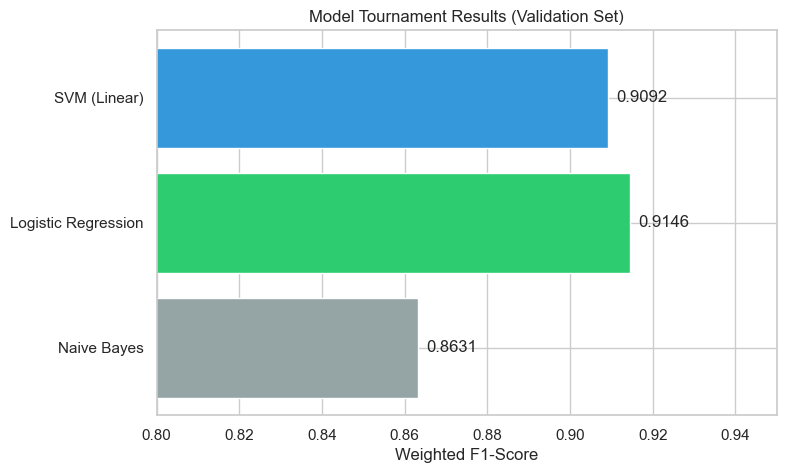

In [6]:
# Visualize tournament results
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != "Object"} for r in results])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(results_df["Model"], results_df["F1-Score"], color=["#95a5a6", "#2ecc71", "#3498db"])
ax.set_xlabel("Weighted F1-Score")
ax.set_title("Model Tournament Results (Validation Set)")
ax.set_xlim(0.8, 0.95)
for bar, val in zip(bars, results_df["F1-Score"]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2, f"{val:.4f}", va="center")

fig.savefig(FIGURES_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Final Evaluation on Test Set

The test set has never been seen during training or model selection.
This gives an unbiased estimate of real-world performance.

In [7]:
best_model = best_run["Object"]
y_test_pred = best_model.predict(X_test_vec)

# On définit le dictionnaire EN PREMIER
LABEL_MAP = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}

# Ensuite on l'utilise
target_names = [LABEL_MAP[i] for i in range(6)]

print("Final Test Report (Unseen Data):")
print(classification_report(y_test, y_test_pred, target_names=target_names))

Final Test Report (Unseen Data):
              precision    recall  f1-score   support

     sadness       0.98      0.93      0.95     18178
         joy       0.98      0.89      0.93     21159
        love       0.74      0.96      0.84      5183
       anger       0.89      0.94      0.92      8597
        fear       0.88      0.86      0.87      7156
    surprise       0.68      0.92      0.78      2246

    accuracy                           0.91     62519
   macro avg       0.86      0.92      0.88     62519
weighted avg       0.92      0.91      0.92     62519



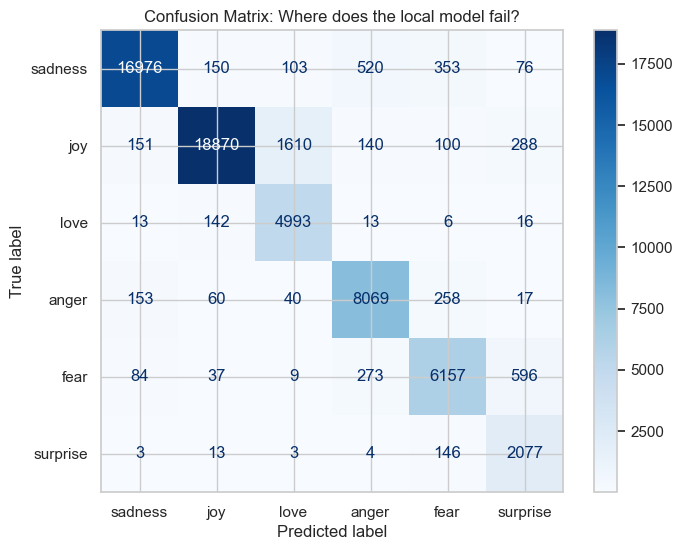

In [8]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix: Where does the local model fail?")

fig.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Export Model Artifacts

We save the trained model and vectorizer as `.pkl` files.
These are loaded by `src/tools.py` at runtime.

In [9]:
joblib.dump(best_model, MODELS_DIR / "LogisticRegression.pkl")
joblib.dump(vectorizer, MODELS_DIR / "tfidf_vectorizer.pkl")

print(f"Model saved to {MODELS_DIR / 'LogisticRegression.pkl'}")
print(f"Vectorizer saved to {MODELS_DIR / 'tfidf_vectorizer.pkl'}")
print("Ready for deployment in src/tools.py.")

Model saved to c:\Users\ayoub\Desktop\ECAM\Bloc 5 Q2\0. Projet info pour stage et github\4. MindCare\mindcare-agent\models\LogisticRegression.pkl
Vectorizer saved to c:\Users\ayoub\Desktop\ECAM\Bloc 5 Q2\0. Projet info pour stage et github\4. MindCare\mindcare-agent\models\tfidf_vectorizer.pkl
Ready for deployment in src/tools.py.
